***
# SECTION 0: DATA DESIGN
***

The following code chunk contains the core dataset source used across both Ride Demand, and Average Fare.

Both datasets aggregate slightly differently, and so the central function, called `read_agg()`, allows for various groupby inputs.

1. Firstly, read the 12 months of New York taxi csv files
    - sourced from: <https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page>
2. Fetch a New York weather dataset
    - documentation: <https://mesonet.agron.iastate.edu/nws/cf6table.php?station=KNYC&opt=bystation&year=2024>
    - API call: <https://mesonet.agron.iastate.edu/json/cf6.py?station=KNYC&year=2024>
    - originally reported by the *US National Weather Service*
3. Add a hard-coded calendar
    - sourced from: <https://www.officeholidays.com/countries/usa/new-york/2024>

## **[0.1]** Main Dataset

In [1]:
seed = 123 # random state seed

import pandas as pd
import requests
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

##############################################################################
#
# Return only one month from `data/` dircectory.
#
# <https://studres.cs.st-andrews.ac.uk/ID5059/Coursework/P2/data/>
# <https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page>
def read_single_month(month=1):
    path = f"./data/nyc_taxi_2024-{month:02d}.csv"
    df = pd.read_csv(
        path, 
        parse_dates = ["tpep_pickup_datetime", "tpep_dropoff_datetime"],
        dtype = {"store_and_fwd_flag": str}
    )
    return df

##############################################################################
#
# Read all 12 csvs into 1 dataframe
#
# `nyc_taxi_2024-*.csv` & `taxi_zone_lookup.csv` expected in the `data/` directory
#
# <https://studres.cs.st-andrews.ac.uk/ID5059/Coursework/P2/data/>
# <https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page>
def raw(month_start=1, month_end=2):
    df = pd.DataFrame() # Empty, base df

    # `month_end+1` because the loop stops 1 before end
    for month in range(month_start, month_end+1):
        tmp = read_single_month(month=month)
        df = pd.concat([df, tmp], ignore_index=True) 

    return df

# Optional: time of day label (useful for report visualisations)
def get_time_of_day(hour):
    if 0 <= hour < 6:
        return "Late Night"
    elif 6 <= hour < 10:
        return "Morning Rush"
    elif 10 <= hour < 16:
        return "Midday"
    elif 16 <= hour < 20:
        return "Evening Rush"
    else:
        return "Evening"

##############################################################################
#
# Transformed version of the dataset, but still **unaggregated**.
#
# 1. cleans dataset for: invalid fares, invalid distances, where pickup is after dropoff
#    and missing pickup items
#
# 2. transforms:
#   a. timeperiod aggregates (what hour, day, week, etc.)
#   b. change `store_and_fwd_flag` from {'Y', 'N'} -> True/False
#   c. real `ratecode` from ID
#   d. real `payment_type` from ID
#   e. real `vendor` from ID
#   f. real `taxi zone` from ID (both pickup zone & dropoff zone)
#   g. real `service zone` from ID (more abstract version of `taxi zone`)
#   h. include `route` taken, i.e. string of `pickup zone` + `dropoff zone`
#   i. same as (h.), but for service zones, as well
#
# 3. drop ID columns
#
# 4. typecast all `object` types -> `category` (expect `store_and_fwd_flag`, which
#    is a boolean)
def clean_single_month(month=1):
    # df = raw(month_start=month_start, month_end=month_end)
    df = read_single_month(month=month)

    # ----------------------------------------------------------------------------#

    ### CLEANING

    # Removing rows with invalid fares (negative or zero fare amounts don't make sense)
    df = df[df["fare_amount"] > 0]

    # Remove rows with invalid trip distances
    df = df[df["trip_distance"] > 0]

    # Remove rows where pickup is after dropoff (data error)
    df = df[df["tpep_pickup_datetime"] < df["tpep_dropoff_datetime"]]

    # Remove any rows with missing pickup times
    df = df.dropna(subset=["tpep_pickup_datetime"])

    # ----------------------------------------------------------------------------#

    ### TRANSFORMATIONS
    #
    # Time aggregates
    df['pickup_date'] = pd.to_datetime(df['tpep_pickup_datetime'].dt.date)
    df['pickup_hr'] = df['tpep_pickup_datetime'].dt.hour
    df['time_of_day'] = df['tpep_pickup_datetime']
    df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
    df['pickup_dow'] = df['tpep_pickup_datetime'].dt.weekday
    df['pickup_week'] = df['tpep_pickup_datetime'].dt.isocalendar().week
    df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
    df['pickup_year'] = df['tpep_pickup_datetime'].dt.year
    df["time_of_day"] = df["tpep_pickup_datetime"].dt.hour.apply(get_time_of_day)

    # # Never used these in the end
    #
    # df['dropoff_hr'] = df['tpep_dropoff_datetime'].dt.hour
    # df['dropoff_day'] = df['tpep_dropoff_datetime'].dt.day
    # df['dropoff_dow'] = df['tpep_dropoff_datetime'].dt.weekday
    # df['dropoff_week'] = df['tpep_dropoff_datetime'].dt.isocalendar().week
    # df['dropoff_month'] = df['tpep_dropoff_datetime'].dt.month
    # df['dropoff_year'] = df['tpep_dropoff_datetime'].dt.year

    # store_and_fwd_flag
    #
    # This flag indicates whether the trip record was held in vehicle memory before
    # sending to the vendor, aka “store and forward,” because the vehicle did not
    # have a connection to the server.
    # Y = store and forward trip
    # N = not a store and forward trip
    #
    # Change flag from 'Y' or 'N' -> True or False
    df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'Y': True, 'N': False})

    # RatecodeID
    #
    # The final rate code in effect at the end of the trip.
    # 1 = Standard rate
    # 2 = JFK
    # 3 = Newark
    # 4 = Nassau or Westchester
    # 5 = Negotiated fare
    # 6 = Group ride
    # 99 = Null/unknown
    # ratecode_mapping = {
    #     1: "Standard Rate",
    #     2: "JFK",
    #     3: "Newark",
    #     4: "Nassua or Westchester",
    #     5: "Negotiated fare",
    #     6: "Group Ride",
    #     99: "Null/unknown",
    # }
    # df['ratecode'] = df['RatecodeID'].map(ratecode_mapping)

    # payment_type
    #
    # A numeric code signifying how the passenger paid for the trip.
    # 0 = Flex Fare trip
    # 1 = Credit card
    # 2 = Cash
    # 3 = No charge
    # 4 = Dispute
    # 5 = Unknown
    # 6 = Voided trip
    # payment_type_mapping = {
    #     0: "Flex Fare trip",
    #     1: "Credit card",
    #     2: "Cash",
    #     3: "No charge",
    #     4: "Dispute",
    #     5: "Unknown",
    #     6: "Voided trip",
    # }
    # df['payment_type'] = df['payment_type'].map(payment_type_mapping)

    # VendorID
    #
    # A code indicating the TPEP provider that provided the record.
    # 1 = Creative Mobile Technologies, LLC
    # 2 = Curb Mobility, LLC
    # 6 = Myle Technologies Inc
    # 7 = Helix
    # vendor_mapping = {
    #     1: "Creative Mobile Technologies, LLC",
    #     2: "Curb Mobility, LLC",
    #     6: "Myle Technologies Inc",
    #     7: "Helix",
    # }
    # df['vendor'] = df['VendorID'].map(vendor_mapping)    

    # Taxi zones
    #
    # .csv file needed to lookup codes
    zones = pd.read_csv("./data/taxi_zone_lookup.csv")
    manhattan_ids = zones[zones["Borough"] == "Manhattan"]["LocationID"].tolist()

    # Taxi zones: Pickup zone & pickup service zone
    df = df[df["PULocationID"].isin(manhattan_ids)]
    df = df.merge(
        zones[['LocationID', 'Zone']].rename(columns={
            'Zone': 'pickup_zone',
            # 'service_zone': 'pickup_service_zone',
        }),
        left_on='PULocationID', 
        right_on='LocationID',
        how='left'
    )
    df = df.drop(columns=['LocationID'])

    # Taxi zones: Dropoff zone & dropoff service zone
    df = df.merge(  
        zones[['LocationID', 'Borough', 'Zone']].rename(columns={
            'Zone': 'dropoff_zone',
            # 'service_zone': 'dropoff_service_zone',
        }),
        left_on='DOLocationID', 
        right_on='LocationID',
        how='left'
    )
    df = df.drop(columns=['LocationID'])
    
    # If the dropoff zone ends in "Airport", keep it as is; otherwise, rename it as "Outside Manhattan"
    is_airport = df['dropoff_zone'].str.endswith('Airport', na=False)
    is_manhattan = df['Borough'] == 'Manhattan'
    df['dropoff_zone'] = np.where(is_airport | is_manhattan, df['dropoff_zone'], 'Outside Manhattan')
    df = df.drop(columns=['Borough'])

    # Taxi zones: route taken
    df['route'] = df['pickup_zone'].astype(str) + " to " + df['dropoff_zone'].astype(str)

    # ----------------------------------------------------------------------------#

    ### DROP COLUMNS
    columns_to_drop = [
        'RatecodeID',
        'VendorID',
        'PULocationID',
        'DOLocationID',
        'store_and_fwd_flag',
    ]
    df = df.drop(columns=columns_to_drop)


    ### TYPE CAST
    df = df.astype({
        # 'store_and_fwd_flag': 'bool',
        # 'payment_type': 'category',
        # 'ratecode': 'category',
        # 'vendor': 'category',
        'pickup_zone': 'category',
        # 'pickup_service_zone': 'category',
        'dropoff_zone': 'category',
        # 'dropoff_service_zone': 'category',
        'route': 'category',
        # 'service_route': 'category',
    })

    # Only 2024 data
    df = df[df['pickup_year'] == 2024]

    return df


##############################################################################
#
# Documentation:
#     <https://mesonet.agron.iastate.edu/nws/cf6table.php?station=KNYC&opt=bystation&year=2024>
#
# The API specifically calls:
#     <https://mesonet.agron.iastate.edu/json/cf6.py?station=KNYC&year=2024>
#
def read_weather_data():
    # Using new API
    response = requests.get("https://mesonet.agron.iastate.edu/json/cf6.py?station=KNYC&year=2024").json()
    wthr = pd.DataFrame(response['results'])
    wthr['date'] = pd.to_datetime(wthr['valid'])
    wthr = wthr.drop(columns=['name', 'station', 'valid', 'state', 'wfo', 'link', 'product', 'minutes_sunshine', 'possible_sunshine', 'hdd', 'cdd', 'gust_drct', 'avg_drct', 'snowd_12z', 'avg_smph'])

    # UNUSED: showed minimal prediction
    # 
    # CF6 Code	Abbrev	Meaning
    # 1	FG	Fog or Mist
    # 2	DNSEFG	Fog or Vis 0.25 mile or less
    # 3	TS	Thunder
    # 4	IP	Ice pellets
    # 5	GR	Hail
    # 6	FZRA	Freezing Rain or Drizzle
    # 7	DSTSTM	Duststorm or Sandstorm vis 0.25 mile or less
    # 8	HZ	Smoke or Haze
    # 9	BLSN	Blowing Snow
    # X	TOR	Tornado
    # M	M	Missing Data
    # wthr['fog']           = wthr['wxcodes'].str.contains('1', na=False).astype(bool)
    # wthr['low_vis']       = wthr['wxcodes'].str.contains('2', na=False).astype(bool)
    # wthr['thunder']       = wthr['wxcodes'].str.contains('3', na=False).astype(bool)
    # wthr['ice']           = wthr['wxcodes'].str.contains('4', na=False).astype(bool)
    # wthr['hail']          = wthr['wxcodes'].str.contains('5', na=False).astype(bool)
    # wthr['freezing_rain'] = wthr['wxcodes'].str.contains('6', na=False).astype(bool)
    # wthr['duststorm']     = wthr['wxcodes'].str.contains('7', na=False).astype(bool)
    # wthr['haze']          = wthr['wxcodes'].str.contains('8', na=False).astype(bool)
    # wthr['blowing_snow']  = wthr['wxcodes'].str.contains('9', na=False).astype(bool)
    # wthr['tornado']       = wthr['wxcodes'].str.contains('X', na=False).astype(bool)

    # A lot of numerical values can include 'T' as an entry
    #
    # This refers to 'trace amounts', i.e. miniscule levels of precipitation; we will just replace with 0
    wthr.replace('T', 0, inplace=True)
    wthr.replace('M', np.nan, inplace=True)
    wthr = wthr.infer_objects(copy=False)

    wthr = wthr.drop(columns=[
        'wxcodes', # redundant
        'avg_temp', # using 'high'
        'dep_temp', # using 'high'
        'low', # using 'high'
        'gust_smph', # using 'max_smph'
        'snow',
        'precip',
    ])

    wthr = wthr.rename(columns={
        'high': 'max_temp',
        'max_smph': 'max_wind_speed',
        'cloud_ss': 'cloud_coverage',
    })

    # impute 3 missing 'max_wind_speed' values
    wthr['max_wind_speed'] = wthr['max_wind_speed'].interpolate(method='linear')

    return wthr

##############################################################################
#
# Source: <https://www.officeholidays.com/countries/usa/new-york/2024>
#
# | Date | Holiday Name | Holiday Type |
# |------|--------------|--------------|
# | 01/01/2024 | New Year's Day | National |
# | 15/01/2024 | Martin Luther King Jr. Day | National |
# | 12/02/2024 | Lincoln's Birthday | Government |
# | 19/02/2024 | Washington's Birthday | Regional |
# ----------| 31/03/2024 | Easter Sunday | Not a holiday |  <-- removed as it's not actually a public holiday
# ----------| 12/05/2024 | Mother's Day | Not a holiday |  <-- removed as it's not actually a public holiday
# | 27/05/2024 | Memorial Day | National |
# ----------| 16/06/2024 | Father's Day | Not a holiday |   <-- removed as it's not actually a public holiday
# | 19/06/2024 | Juneteenth | Regional |
# | 04/07/2024 | Independence Day | National |
# | 02/09/2024 | Labor Day | National |
# | 14/10/2024 | Columbus Day | Regional |
# | 05/11/2024 | Election Day | Government |
# | 11/11/2024 | Veterans Day | Regional |
# | 28/11/2024 | Thanksgiving | National |
# | 25/12/2024 | Christmas Day | National |
def read_calendar_data():
    data = {
        "date": [
            "01/01/2024", "15/01/2024", "12/02/2024", "19/02/2024",
            "27/05/2024",
            "19/06/2024", "04/07/2024", "02/09/2024", "14/10/2024",
            "05/11/2024", "11/11/2024", "28/11/2024", "25/12/2024"
        ],
        "holiday": [
            "New Year's Day", "Martin Luther King Jr. Day", "Lincoln's Birthday",
            "Washington's Birthday",
            "Memorial Day", "Juneteenth", "Independence Day",
            "Labor Day", "Columbus Day", "Election Day", "Veterans Day",
            "Thanksgiving", "Christmas Day"
        ],
        "holiday_type": [
            "National", "National", "Government", "Regional",
            "National", "Regional", "National",
            "National", "Regional", "Government", "Regional", "National", "National"
        ]
    }

    calendar = pd.DataFrame(data)
    calendar["date"] = pd.to_datetime(calendar["date"], format="%d/%m/%Y")
    return calendar

##############################################################################
#
# For many months, clean, aggregated, and append monthly data.
default_groupings = [
    'pickup_month',
    'pickup_week', 
    'pickup_date',
    'pickup_dow', 
    'time_of_day',
    'pickup_zone',
    'dropoff_zone',
    'route',
]
def read_agg(month_start=1, month_end=2, groupings=default_groupings):
    base_df = pd.DataFrame()

    for month in range(month_start, month_end+1):
        print(f"reading data for month {month}")
        tmp_df = clean_single_month(month)
        # tmp_df = tmp_df[tmp_df['pickup_year'] == 2024]
        agg_df = tmp_df.groupby(groupings, as_index=False, observed=True).agg(
            total_ride_count        = ('tpep_pickup_datetime', 'count'),
            avg_fare_amount         = ('fare_amount', 'mean'),
            total_trip_distance     = ('trip_distance', 'sum')
        )
        base_df = pd.concat([base_df, agg_df], ignore_index=True)

    print("collecting weather data")
    weather = read_weather_data()
    base_df = pd.merge(base_df, weather, left_on='pickup_date', right_on='date', how='left')
    base_df = base_df.drop(columns=['date'])

    print("collecting calendar data")
    cal = read_calendar_data()
    base_df = pd.merge(base_df, cal, left_on='pickup_date', right_on='date', how='left')
    base_df['holiday'] = base_df['holiday'].fillna("None")
    base_df = base_df.drop(columns=['date', 'holiday_type'])

    return base_df

## **[0.2]** Helper functions

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Plots feature importance for a model, given a pipeline (usually based in `Prepocessing` sections)
def feature_importance(pipeline, model):
    feature_names = pipeline.get_feature_names_out()
    importances = model.feature_importances_
    feat_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(12,12))
    feat_df.head(20).plot(kind='bar', x='feature', y='importance', figsize=(18, 8))
    plt.tight_layout()
    plt.xticks(rotation=90)
    plt.show()

# Reports MAE, MSE, and R squared scores
# & plots Residuals vs. Predictions, and Actual vs. Predictions
def analysis(y_true, y_pred):
    # Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)
    print(f"Mean Absolute Error: \t{mae:.4f}")

    # Mean Squared Error
    mse = mean_squared_error(y_true, y_pred)
    print(f"Mean Squared Error: \t{mse:.4f}")

    # R squared
    r2 = r2_score(y_true, y_pred)
    print(f"R squared: \t\t{r2:.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Residuals
    residuals = y_true - y_pred
    ax[0].scatter(y_pred, residuals, alpha=.4)
    ax[0].axhline(0, color='black', linestyle='--')
    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("Residuals")
    ax[0].set_title("Residuals")

    # Actual vs predicted
    ax[1].scatter(y_true, y_pred, alpha=.4)
    ax[1].set_xlabel("Actual")
    ax[1].set_ylabel("Predicted")
    ax[1].set_title("Actual vs. Predicted")

***
# SECTION 1: RIDE DEMAND
***

A total of 3 regressor models were trained, in order to predict `ride demand`:
| Model | Reason | Package |
| ----- | ------ | ------- |
| Random Forest | used as a foundation, given the easy-to-understand nature of decision trees | sklearn |
| Light Gradient Boosted Machine | heavily optimized for largescale data, and more suitable for stronger predictions | lightgbm |
| MLP Neural Net | comparison to deep learning approach | sklearn |

## **[1.1]** Dataset

In [3]:
# Read the data in
df = read_agg(month_start=1, month_end=12)

# Calculate `lag_demand`
# 
# In this context, we have `time_of_day` (explained in [1.2]), and so lagged demand means for the current time of day, use the same time of day,
# but but 1 day before
daily = df.groupby(['pickup_date', 'time_of_day', 'route'], as_index=False)['total_ride_count'].sum()
daily = daily.sort_values(['route', 'time_of_day', 'pickup_date'])
daily['lag_demand'] = daily.groupby(['route', 'time_of_day'])['total_ride_count'].shift(1)
df = df.merge(
    daily[['route', 'pickup_date', 'time_of_day', 'lag_demand']],
    on=['time_of_day', 'route', 'pickup_date'],
    how='left'
)
df['lag_demand'] = df['lag_demand'].fillna(0)

# Recast datatypes
df = df.astype({
    'pickup_zone': 'category',
    'route': 'category',
    'time_of_day': 'category',
    'holiday': 'bool',
})

df.info()

reading data for month 1
reading data for month 2
reading data for month 3
reading data for month 4
reading data for month 5
reading data for month 6
reading data for month 7
reading data for month 8
reading data for month 9
reading data for month 10
reading data for month 11
reading data for month 12
collecting weather data


C:\Users\lgrun\AppData\Local\Temp\ipykernel_20456\2827865467.py:306: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('T', 0, inplace=True)
C:\Users\lgrun\AppData\Local\Temp\ipykernel_20456\2827865467.py:307: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('M', np.nan, inplace=True)


collecting calendar data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4335533 entries, 0 to 4335532
Data columns (total 16 columns):
 #   Column               Dtype         
---  ------               -----         
 0   pickup_month         int32         
 1   pickup_week          UInt32        
 2   pickup_date          datetime64[ns]
 3   pickup_dow           int32         
 4   time_of_day          category      
 5   pickup_zone          category      
 6   dropoff_zone         object        
 7   route                category      
 8   total_ride_count     int64         
 9   avg_fare_amount      float64       
 10  total_trip_distance  float64       
 11  max_temp             int64         
 12  max_wind_speed       float64       
 13  cloud_coverage       float64       
 14  holiday              bool          
 15  lag_demand           float64       
dtypes: UInt32(1), bool(1), category(3), datetime64[ns](1), float64(5), int32(2), int64(2), object(1)
memory usage: 372.3+ M

## **[1.2]** Exploratory Data Analysis

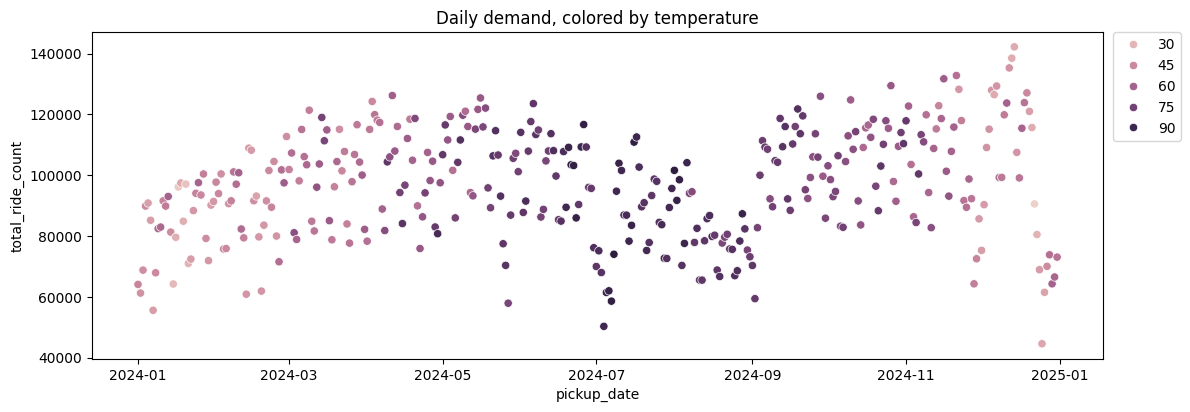

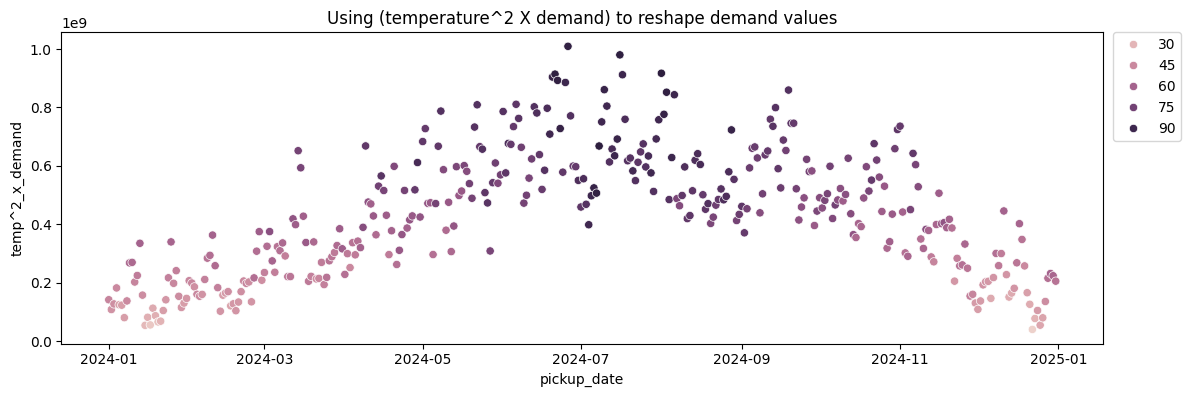

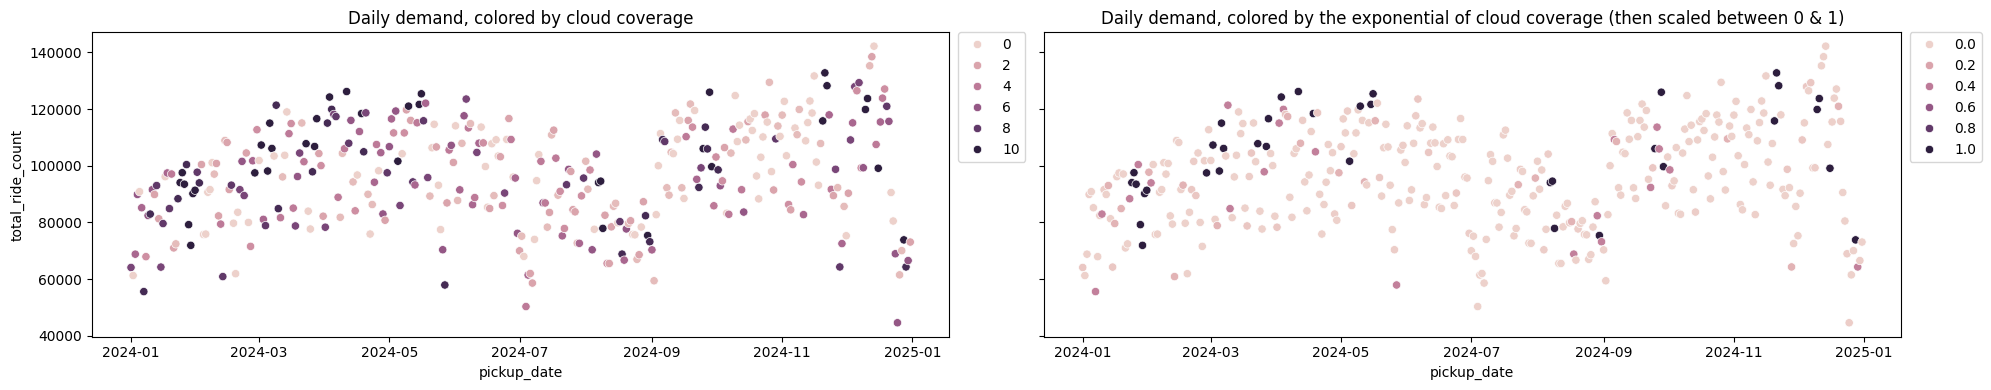

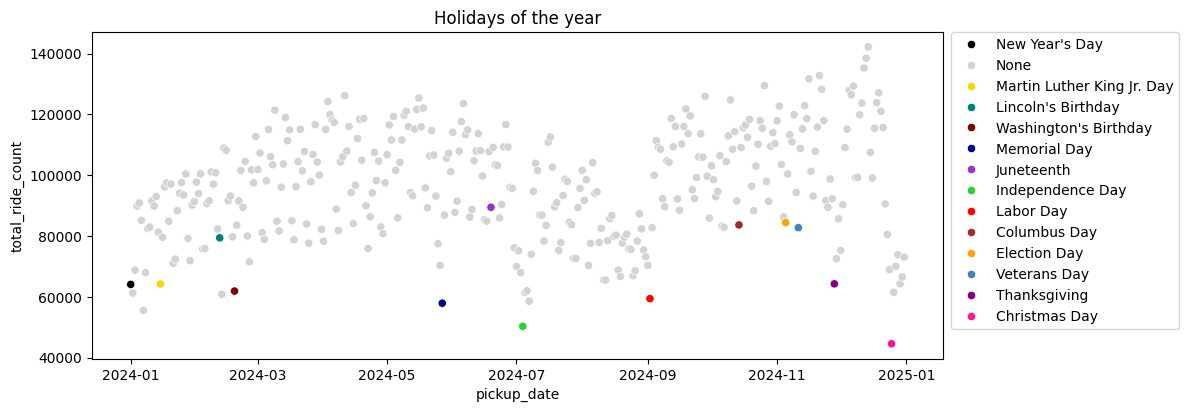

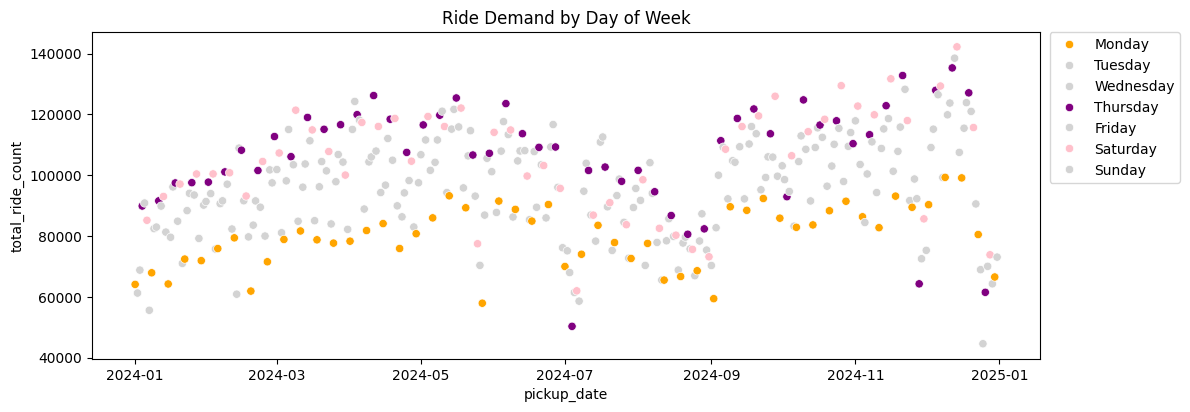

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Daily aggregate for EDA around weather
daily = df.groupby(['pickup_date']).agg(
    total_ride_count=('total_ride_count', 'sum'),
    cloud_coverage=('cloud_coverage', 'mean'),
    max_temp=('max_temp', 'mean'),
    max_wind_speed=('max_wind_speed', 'mean'),
).reset_index()
daily['day'] = daily['pickup_date'].dt.day_name()

# Join calendar
calendar = read_calendar_data()
daily = daily.merge(
    calendar,
    left_on='pickup_date',
    right_on='date',
    how='left'
)
daily['holiday'] = daily['holiday'].fillna("None")

# Does temperature requiring scaling?
daily['temp^2_x_demand'] = daily['max_temp'] * daily['max_temp'] * daily['total_ride_count']

plt.figure(figsize=(12, 4))
sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='max_temp')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.title("Daily demand, colored by temperature")
plt.show()

plt.figure(figsize=(12, 4))
sns.scatterplot(daily, x='pickup_date', y='temp^2_x_demand', hue='max_temp')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.title("Using (temperature^2 X demand) to reshape demand values")
plt.show()

# Cloud cover & Windspeed saying similar things; can they be combined?
daily['exp_cloud_cover'] = np.exp(daily['cloud_coverage'])
daily['scaled_exp_cloud_cover'] = MinMaxScaler().fit_transform(daily['exp_cloud_cover'].values.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(20, 4), sharey=True)
sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='cloud_coverage', ax=axes[0])
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
axes[0].set_title("Daily demand, colored by cloud coverage")
sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='scaled_exp_cloud_cover', ax=axes[1])
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
axes[1].set_title("Daily demand, colored by the exponential of cloud coverage (then scaled between 0 & 1)")
plt.tight_layout()
plt.show()

# Look at holidays
palette = {
    'None': 'lightgrey',
    'Labor Day': 'red',
    'Veterans Day': 'steelblue',
    'Independence Day': 'limegreen',
    'Election Day': 'orange',
    'Thanksgiving': 'purple',
    'Christmas Day': 'deeppink',
    'Columbus Day': 'brown',
    'Memorial Day': 'navy',
    'Martin Luther King Jr. Day': 'gold',
    "Lincoln's Birthday": 'teal',
    "New Year's Day": 'black',
    "Washington's Birthday": 'maroon',
    'Juneteenth': 'darkorchid'
}
plt.figure(figsize=(12, 4))
sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='holiday', palette=palette)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.title("Holidays of the year")
plt.show()

# Days of week
palette = {
    'Monday': "orange",
    'Tuesday': 'lightgrey',
    'Wednesday': 'lightgrey',
    'Thursday': 'purple',
    'Friday': 'lightgrey',
    'Saturday': 'pink',
    'Sunday': 'lightgrey',
}
plt.figure(figsize=(12, 4))
sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='day', palette=palette)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.title("Ride Demand by Day of Week") # "I hate Mondays" is not descriptive
plt.show()

del daily

## **[1.3]** Preprocessing

In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Recast object types -> category (just to be sure)
df = df.astype({
    'pickup_zone': 'category',
    'route': 'category',
    'time_of_day': 'category',
    'holiday': 'category',
})

# Remove waste columns
df = df.drop(errors='ignore', columns=[
    # 'lag_demand',
    'dropoff_zone',
    'pickup_date',
    'service_route',
    'pickup_service_zone',
    'dropoff_service_zone',
    'pickup_week',
    'pickup_day',  
    'avg_fare_amount',
    'total_trip_distance',
])

# This transformation gives 99% accuracy - overfitting is very debatable
# df['demand_x_temp^2'] = df['total_ride_count'] * df['max_temp'] * df['max_temp'] # Scale temperature with lag demand

# These columns only have a few categories
#
# => onehot encoding is okay
columns_to_onehot_encode = [
    'pickup_dow',
    'time_of_day',
]

# These columns have LOADS of categories
#
# => ordinal encoding is needed             <---- not doing this gives 500GB encoded dataset
#``
# (tried TargetEncoder, but still ended up at 22GB - sticking to ordinal)
columns_to_ordinal_encode = [
    'pickup_zone',
    'route',
    'holiday',
]



# Split `y` BEFORE pipeline
y = df['total_ride_count']
# placeholder = df['avg_fare_amount']
X = df.drop(columns=['total_ride_count'])

# Pipeline
#
# Transfroms the categorical columns to onehot-encoded types
pipeline = ColumnTransformer(
    transformers=[
        #                               +--- `sparse_output=True` stops the encoder duplicating data
        #                               |
        ("onehot", OneHotEncoder(sparse_output=True), columns_to_onehot_encode), 
        ("ordinal", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_ordinal_encode),
    ],
    remainder='passthrough'
)
# pipeline.set_output(transform='pandas') # returning pandas cost too much memory
X_encoded = pipeline.fit_transform(X)

# Train vs Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=seed)

# Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=seed)

## **[1.4]** Random Forest Model

Mean Absolute Error: 	0.0223
Mean Squared Error: 	0.1707
R squared: 		0.9990
Mean Absolute Error: 	0.0469
Mean Squared Error: 	0.7373
R squared: 		0.9955
Mean Absolute Error: 	0.0449
Mean Squared Error: 	0.6561
R squared: 		0.9960


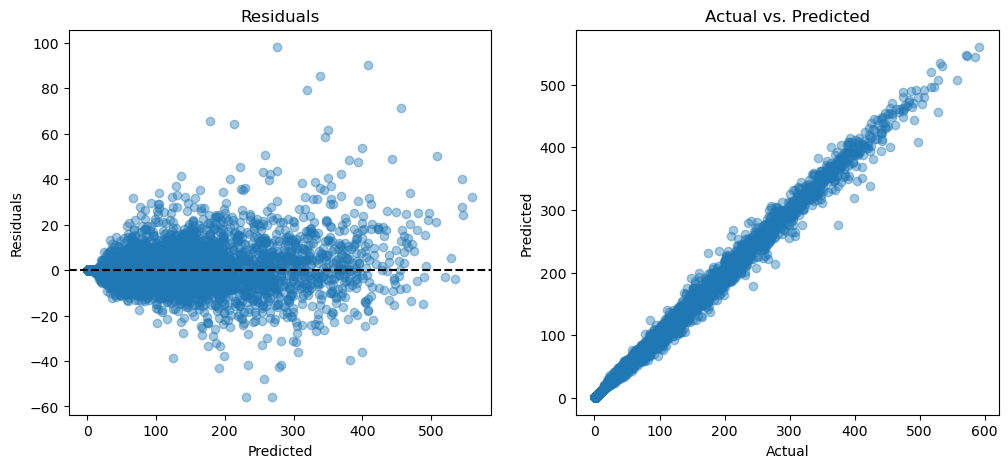

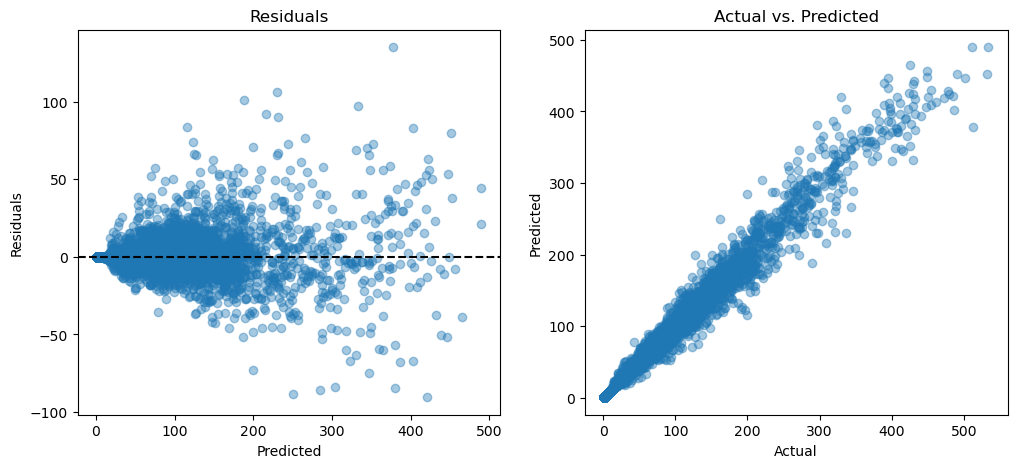

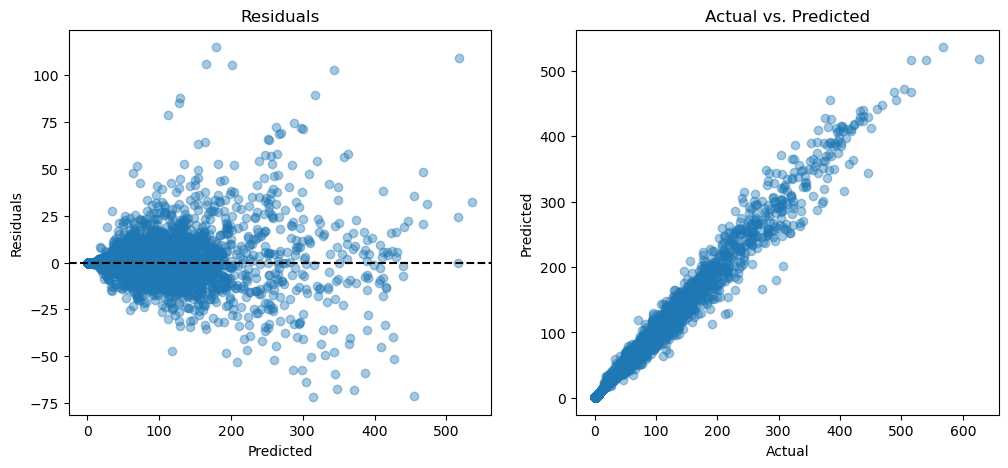

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Fine-tuned model
rf = RandomForestRegressor(
    n_jobs=1,           # parallel compute tends to crash memory (keep it at 1)
    n_estimators=75,    # need reduced processing
    min_samples_leaf=2, # weird clustering around `250` & `400` predictions without this
    max_depth=25,       # maxdepth=25 is large, but there are a lot of features, and validation/testing remain similar to training
    #
    # criterion='absolute_error'        # very low values being mis-assigned    <-------    took too long to compute
)
rf.fit(X_train, y_train)

# Training results
training_predictions = rf.predict(X_train)
analysis(y_train, training_predictions)

# Validation Results
validation_predictions = rf.predict(X_val)
analysis(y_val, validation_predictions)

# Test Results
test_predictions = rf.predict(X_test)
analysis(y_test, test_predictions)

# Clean up (for memory)
del rf
del training_predictions
del validation_predictions
del test_predictions

## **[1.5]** Light Gradient-Boosting Machine Model

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 911
[LightGBM] [Info] Number of data points in the train set: 2427898, number of used features: 20
[LightGBM] [Info] Start training from score 8.131009


/nix/store/dsb2bm1c5ca7k33f72iv2vim1hd6xf68-python3-3.13.12-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Mean Absolute Error: 	0.1814
Mean Squared Error: 	1.0733
R squared: 		0.9945


/nix/store/dsb2bm1c5ca7k33f72iv2vim1hd6xf68-python3-3.13.12-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Mean Absolute Error: 	0.1895
Mean Squared Error: 	1.5527
R squared: 		0.9922


/nix/store/dsb2bm1c5ca7k33f72iv2vim1hd6xf68-python3-3.13.12-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Mean Absolute Error: 	0.1899
Mean Squared Error: 	1.5784
R squared: 		0.9919


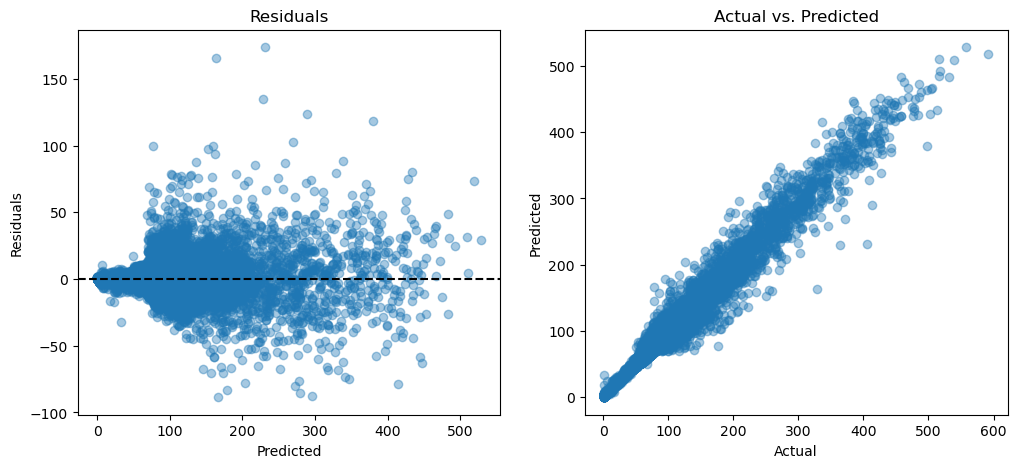

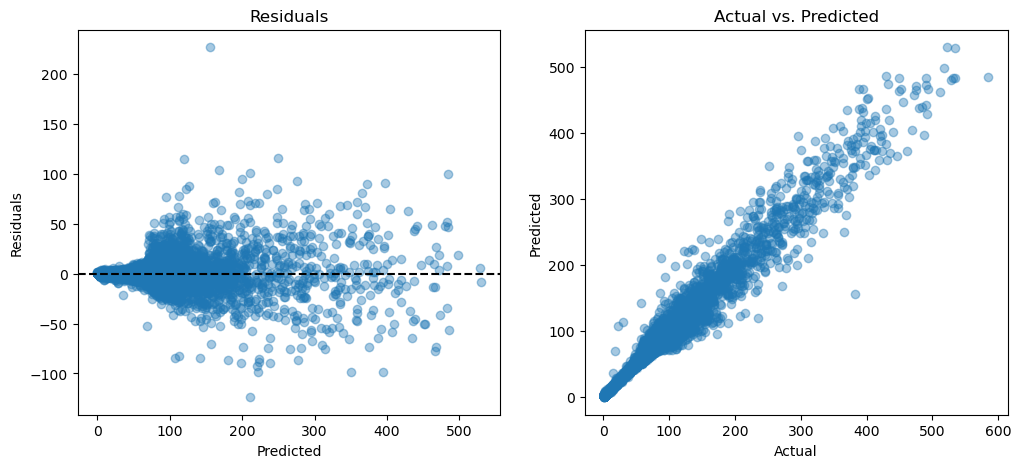

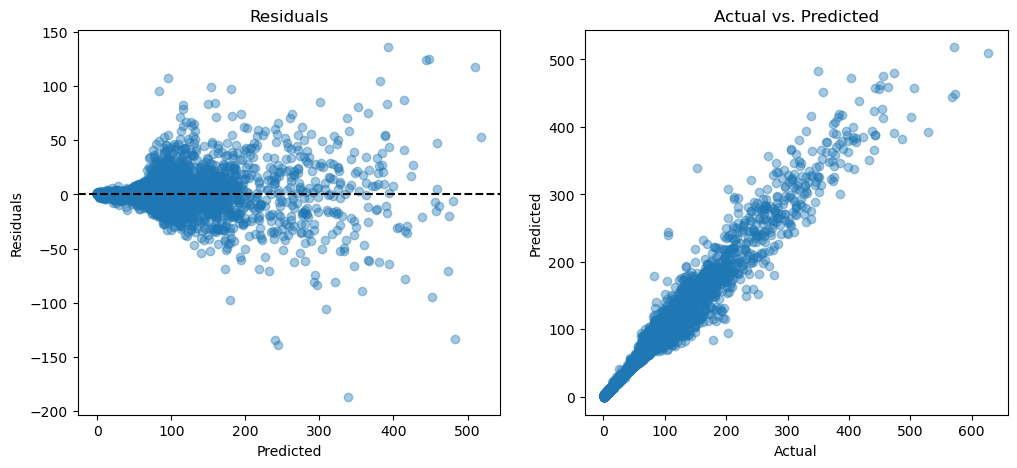

<Figure size 1200x1200 with 0 Axes>

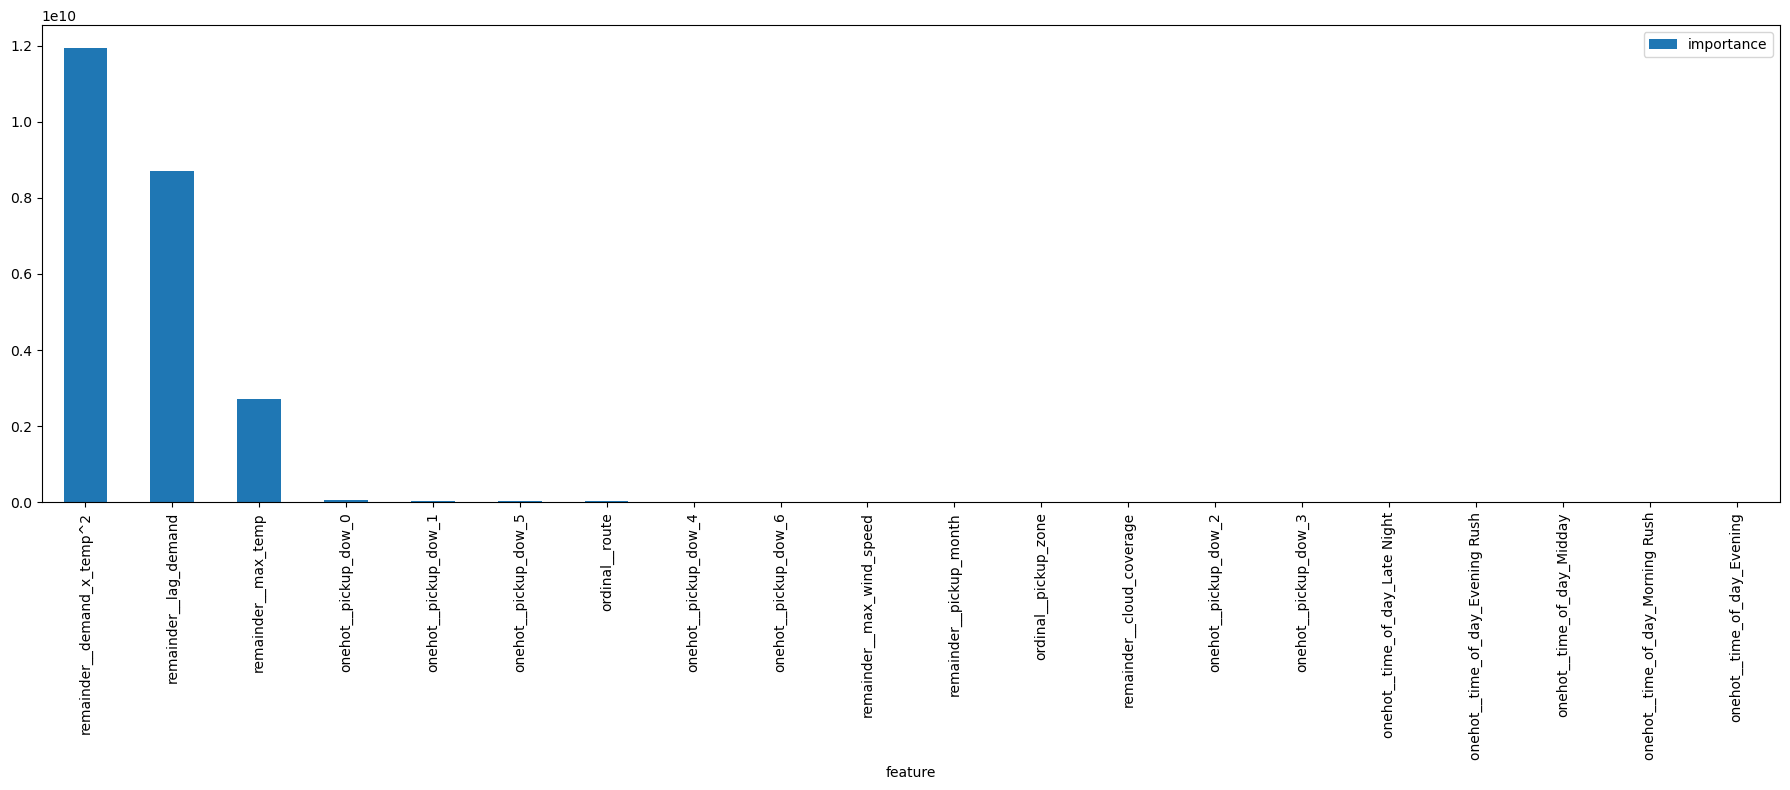

In [29]:
from lightgbm import LGBMRegressor

lg = LGBMRegressor(
    random_state=seed,
    num_threads=1,
    learning_rate=0.01,
    n_estimators=1000,
    num_leaves=60, # default=31 <--- using alot more leaves than usual 
    max_depth=-1, # unlimited tree depth (this algorithm is focused on width, more than depth)

    # The type of feature importance to be filled into feature_importances_. 
    # If ‘split’, result contains numbers of times the feature is used in a model. 
    #
    # If ‘gain’, result contains total gains of splits which use the feature.
    # importance_type='split',
    importance_type='gain',
)
lg.fit(X_train, y_train)

# Training results
training_predictions = lg.predict(X_train)
analysis(y_train, training_predictions)

# Validation Results
validation_predictions = lg.predict(X_val)
analysis(y_val, validation_predictions)

# Test Results
test_predictions = lg.predict(X_test)
analysis(y_test, test_predictions)

feature_importance(pipeline, lg)

# Clean up (for memory)
del lg
del training_predictions
del validation_predictions
del test_predictions

## **[1.6]** MLP Neural Net Model

Mean Absolute Error: 	1.1169
Mean Squared Error: 	5.5196
R squared: 		0.9669
Mean Absolute Error: 	1.1185
Mean Squared Error: 	5.5557
R squared: 		0.9663
Mean Absolute Error: 	1.1138
Mean Squared Error: 	5.3580
R squared: 		0.9675


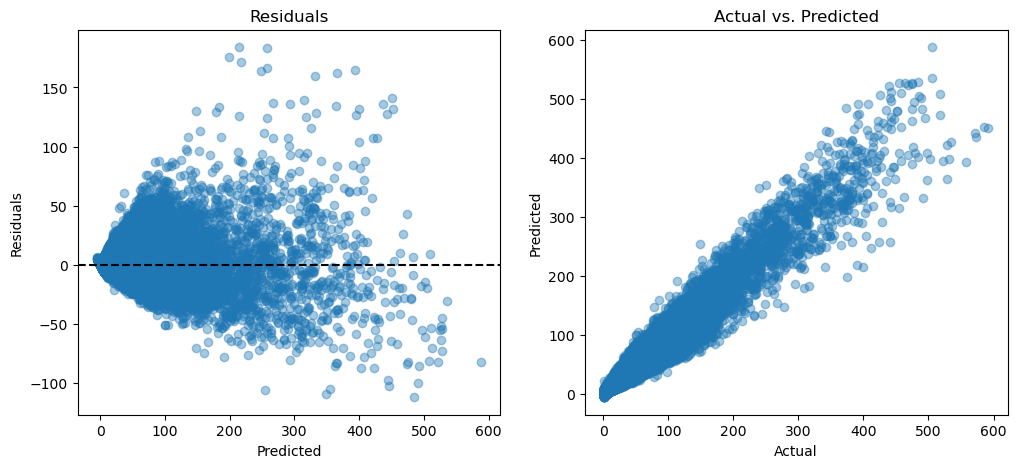

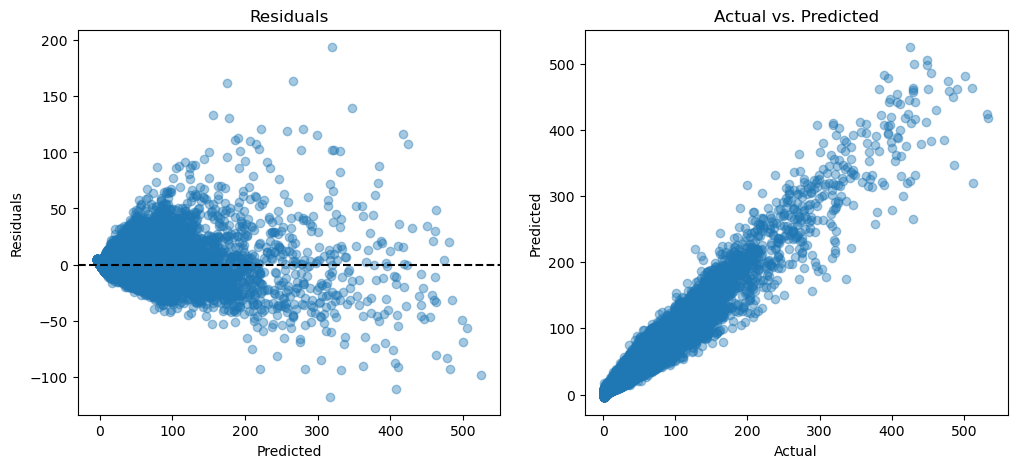

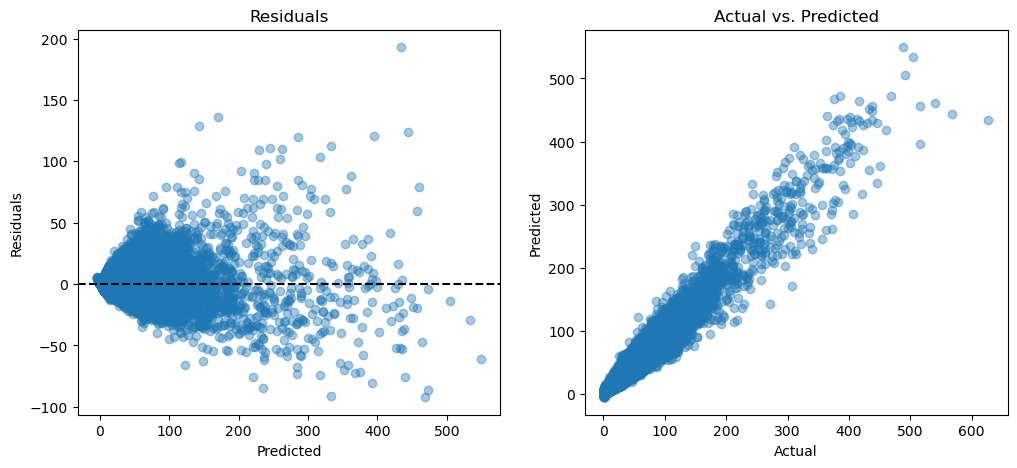

In [ ]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(
    random_state=seed, 
    activation='relu',
    max_iter=2000, # the algo needs a lot of time to learn
    tol=0.1 # tolerance
)
nn.fit(X_train, y_train)

# Training results
training_predictions = nn.predict(X_train)
analysis(y_train, training_predictions)

# Validation Results
validation_predictions = nn.predict(X_val)
analysis(y_val, validation_predictions)

# Test Results
test_predictions = nn.predict(X_test)
analysis(y_test, test_predictions)

# Clean up (for memory)
del nn
del training_predictions
del validation_predictions
del test_predictions

In [6]:
# Clean up before section 2
del df
del pipeline
del y, X
del X_encoded, X_train, y_train, X_val, y_val, X_test, y_test

***
# SECTION 2: AVERAGE FARE AMOUNT
***

3 models for predicting the **fare amount of each ride**:
1. Linear
2. Random Forest
3. MLP Neural Net

## **[2.1]** Dataset

In [16]:
groupby = [
    'pickup_month',
    'pickup_week', 
    'pickup_date',
    'pickup_dow',
    'pickup_hr',
    'pickup_zone',
]
df = read_agg(groupings=groupby, month_start=1, month_end=12)
df.info()

reading data for month 1
reading data for month 2
reading data for month 3
reading data for month 4
reading data for month 5
reading data for month 6
reading data for month 7
reading data for month 8
reading data for month 9
reading data for month 10
reading data for month 11
reading data for month 12
collecting weather data


C:\Users\lgrun\AppData\Local\Temp\ipykernel_20456\2827865467.py:306: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('T', 0, inplace=True)
C:\Users\lgrun\AppData\Local\Temp\ipykernel_20456\2827865467.py:307: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('M', np.nan, inplace=True)


collecting calendar data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507811 entries, 0 to 507810
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   pickup_month         507811 non-null  int32         
 1   pickup_week          507811 non-null  UInt32        
 2   pickup_date          507811 non-null  datetime64[ns]
 3   pickup_dow           507811 non-null  int32         
 4   pickup_hr            507811 non-null  int32         
 5   pickup_zone          507811 non-null  object        
 6   total_ride_count     507811 non-null  int64         
 7   avg_fare_amount      507811 non-null  float64       
 8   total_trip_distance  507811 non-null  float64       
 9   max_temp             507811 non-null  int64         
 10  max_wind_speed       507811 non-null  float64       
 11  cloud_coverage       507811 non-null  float64       
 12  holiday              507811 non-null  object   

In [17]:
# Calculate lag demand and lag average fare (every hour)
hourly = df.groupby(['pickup_date', 'pickup_hr', 'pickup_zone'], as_index=False).agg(
    avg_fare_amount = ('avg_fare_amount', 'mean'),
    demand = ('total_ride_count', 'sum'),
)
hourly = hourly.sort_values(['pickup_zone', 'pickup_date', 'pickup_hr'])
hourly['avg_fare_lag_1h'] = hourly.groupby(['pickup_zone'])['avg_fare_amount'].shift(1).fillna(0)
hourly['demand_lag_1h'] = hourly.groupby(['pickup_zone'])['demand'].shift(1).fillna(0)

hourly[hourly['pickup_zone'] == "Alphabet City"]
df = df.drop(columns=['avg_fare_lag_1h_x', 'avg_fare_lag_1h_y', 'demand_lag_1h_x', 'demand_lag_1h_y'], errors='ignore')
df = df.merge(
    hourly[['pickup_zone', 'pickup_date', 'pickup_hr', 'avg_fare_lag_1h', 'demand_lag_1h']],
    on=['pickup_zone', 'pickup_date', 'pickup_hr'],
    how='left'
)

# Recast object types -> category (just to be sure)
df = df.astype({
    'pickup_zone': 'category',
    'holiday': 'category',
})

df.head(3)
del hourly

## **[2.2]** Exploratory Data Analysis

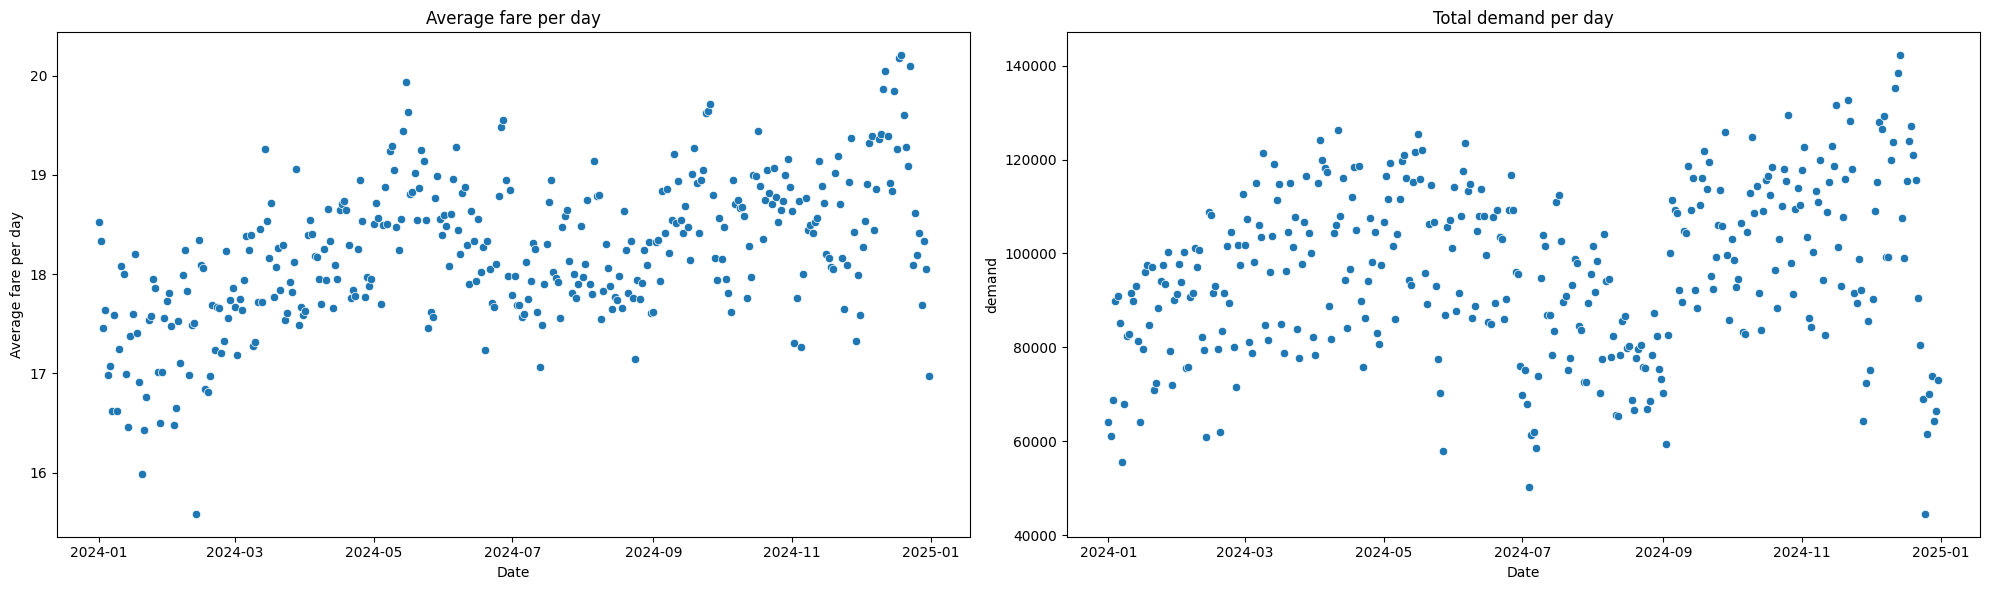

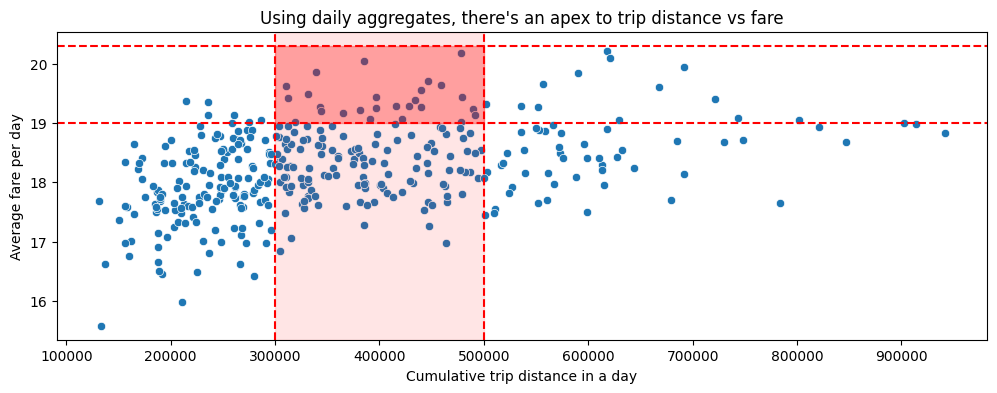

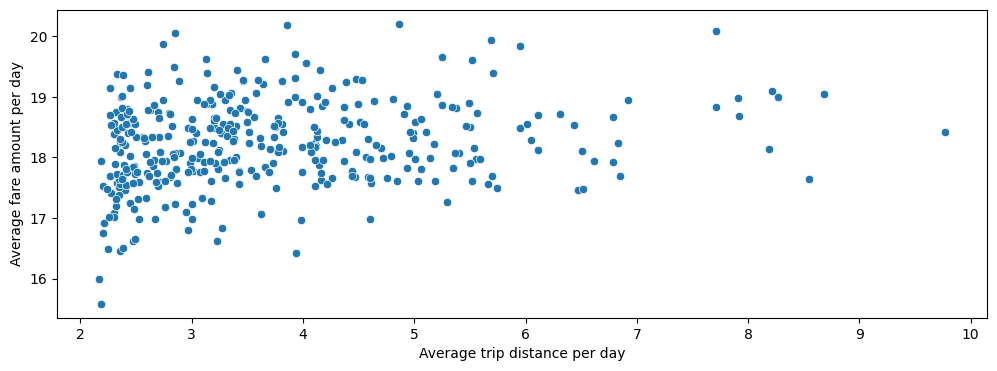

In [18]:
# Trip distance vs. Avg Fare
daily = df.groupby(['pickup_date'], as_index=False).agg(
    avg_fare_amount = ('avg_fare_amount', 'mean'),
    demand = ('total_ride_count', 'sum'),
    total_trip_distance = ('total_trip_distance', 'sum')
)

# Daily Demand & Daily Average Fare have similar seasonal trends across the year
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.scatterplot(daily, x='pickup_date', y='avg_fare_amount', ax=axes[0])
axes[0].set_title("Average fare per day")
sns.scatterplot(daily, x='pickup_date', y='demand', ax=axes[1])
axes[1].set_title("Total demand per day")
axes[0].set_ylabel("Average fare per day")
axes[0].set_xlabel("Date")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# Total trip distance in a day vs Avg fare
plt.figure(figsize=(12, 4))
sns.scatterplot(daily, x='total_trip_distance', y='avg_fare_amount')
plt.title("Using daily aggregates, there's an apex to trip distance vs fare")
plt.axhline(y=20.3, color='red', linestyle='--')
plt.axhline(y=19, color='red', linestyle='--')
plt.axvline(x=500_000, color='red', linestyle='--')
plt.axvline(x=300_000, color='red', linestyle='--')
plt.axvspan(300_000, 500_000, ymin=0, ymax=1, alpha=0.1, color='red')  # vertical band
plt.fill_between([300_000, 500_000], 19, 20.3, alpha=0.3, color='red')   # inner rectangle only
plt.xlabel("Cumulative trip distance in a day")
plt.ylabel("Average fare per day")
plt.show()

# Looking at avg distance vs. avg fare
daily['avg_distance_per_ride'] = daily['total_trip_distance'] / daily['demand']
plt.figure(figsize=(12, 4))
sns.scatterplot(daily, x='avg_distance_per_ride', y='avg_fare_amount')
plt.xlabel("Average trip distance per day")
plt.ylabel("Average fare amount per day")
plt.show()

del daily

### Temporal EDA
Monthly, weekly (days of week), daily (hours of day), and holiday average fare trends.

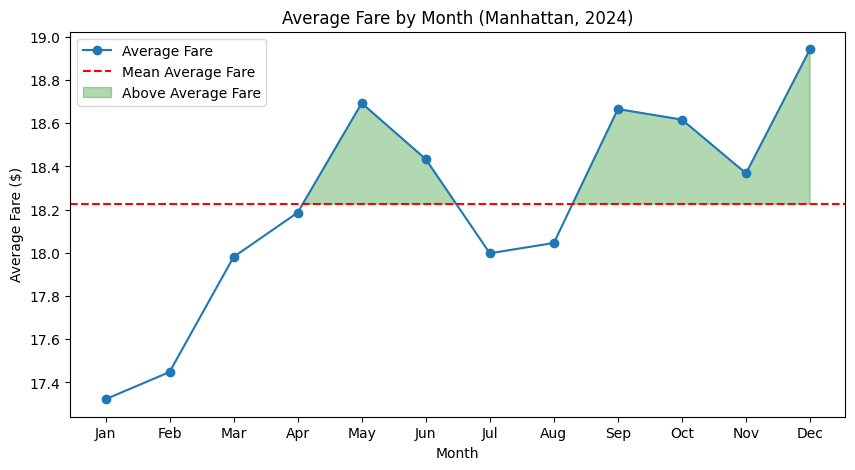

In [54]:
# Monthly - trends
monthly = df.groupby(['pickup_month'], as_index=False).agg(
    avg_fare_amount = ('avg_fare_amount', 'mean'),
    avg_demand = ('total_ride_count', 'mean')
)

# Month names instead of numbers
import calendar
monthly['month_name'] = monthly['pickup_month'].apply(lambda x: calendar.month_abbr[x])

plt.figure(figsize=(10, 5))

# Average fare per month trendline
plt.plot(monthly['month_name'], monthly['avg_fare_amount'], marker='o', label="Average Fare")

# Mean average fare per month (across all months)
plt.axhline(y=monthly['avg_fare_amount'].mean(), color='red', linestyle='--', label="Mean Average Fare")

# Highlight which months have higher than average fares
plt.fill_between(monthly['month_name'], monthly['avg_fare_amount'], monthly['avg_fare_amount'].mean(), where=(monthly['avg_fare_amount'] > monthly['avg_fare_amount'].mean()), color='green', alpha=0.3, label="Above Average Fare", interpolate=True)

plt.title("Average Fare by Month (Manhattan, 2024)")
plt.xlabel("Month")
plt.ylabel("Average Fare ($)")
plt.legend()
plt.show()

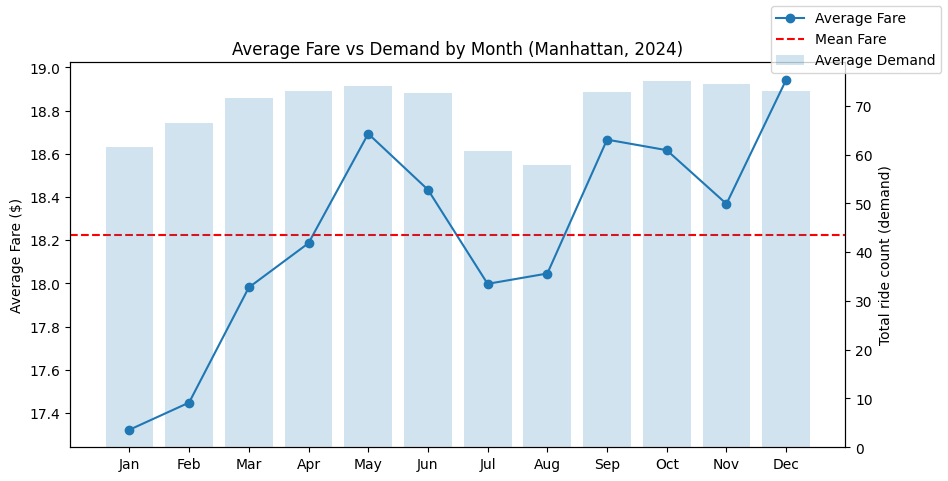

In [55]:
# Monthly - trends (with demand comparison)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Average fare per month trendline
ax1.plot(monthly['month_name'], monthly['avg_fare_amount'], marker='o', label="Average Fare")
# Mean average fare per month (across all months)
ax1.axhline(y=monthly['avg_fare_amount'].mean(), color='red', linestyle='--', label="Mean Fare")
ax1.set_ylabel("Average Fare ($)")

# Show demand in background for context
ax2 = ax1.twinx()
ax2.bar(monthly['month_name'], monthly['avg_demand'], alpha=0.2, label="Average Demand")
ax2.set_ylabel("Total ride count (demand)")

plt.title("Average Fare vs Demand by Month (Manhattan, 2024)")
fig.legend(loc="upper right")
plt.show()

del monthly # (defined in cell above)

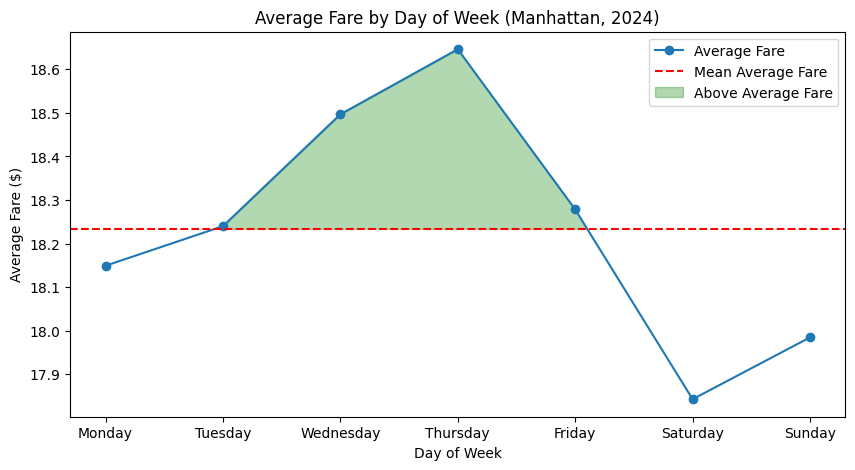

In [61]:
# Weekly (days of week)
weekly = df.groupby(['pickup_dow'], as_index=False).agg(
    avg_fare_amount = ('avg_fare_amount', 'mean'),
    avg_demand = ('total_ride_count', 'mean')
)

# Day names instead of numbers
weekly['day_name'] = weekly['pickup_dow'].apply(lambda x: calendar.day_name[x])

plt.figure(figsize=(10, 5))

# Average fare per month trendline
plt.plot(weekly['day_name'], weekly['avg_fare_amount'], marker='o', label="Average Fare")

# Mean average fare per month (across all months)
plt.axhline(y=weekly['avg_fare_amount'].mean(), color='red', linestyle='--', label="Mean Average Fare")

# Highlight which months have higher than average fares
plt.fill_between(weekly['day_name'], weekly['avg_fare_amount'], weekly['avg_fare_amount'].mean(), where=(weekly['avg_fare_amount'] > weekly['avg_fare_amount'].mean()), color='green', alpha=0.3, label="Above Average Fare", interpolate=True)

plt.title("Average Fare by Day of Week (Manhattan, 2024)")
plt.xlabel("Day of Week")
plt.ylabel("Average Fare ($)")
plt.legend()
plt.show()

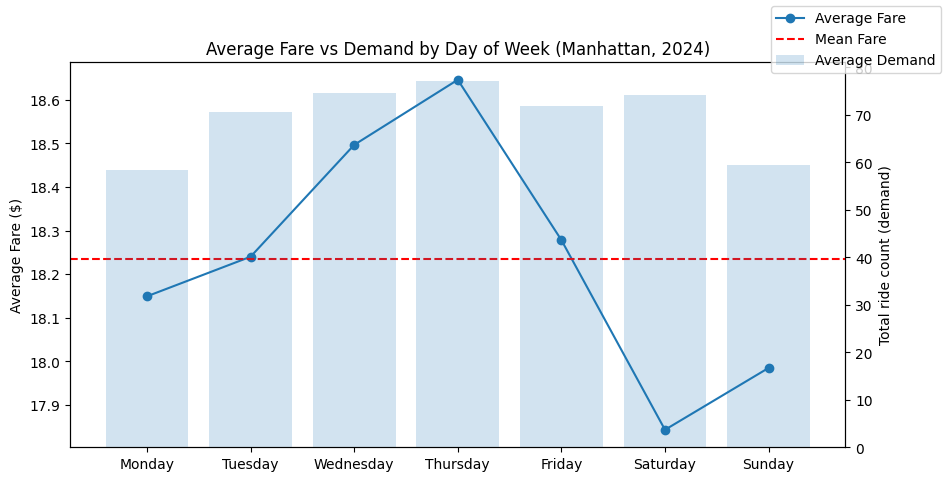

In [62]:
# Weekly - trends (with demand comparison)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Average fare per week trendline
ax1.plot(weekly['day_name'], weekly['avg_fare_amount'], marker='o', label="Average Fare")
# Mean average fare per week (across all weeks)
ax1.axhline(y=weekly['avg_fare_amount'].mean(), color='red', linestyle='--', label="Mean Fare")
ax1.set_ylabel("Average Fare ($)")

# Show demand in background for context
ax2 = ax1.twinx()
ax2.bar(weekly['day_name'], weekly['avg_demand'], alpha=0.2, label="Average Demand")
ax2.set_ylabel("Total ride count (demand)")

plt.title("Average Fare vs Demand by Day of Week (Manhattan, 2024)")
fig.legend(loc="upper right")
plt.show()

del weekly # (defined in cell above)

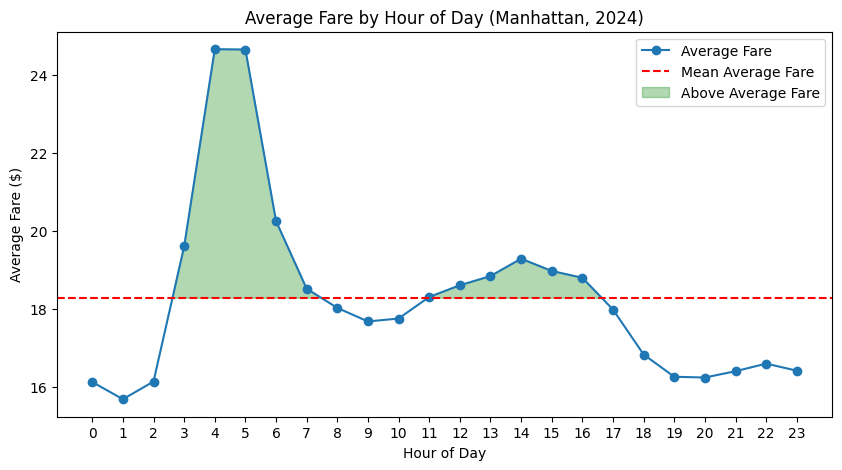

In [74]:
# Hourly (hours of day)
hourly = df.groupby(['pickup_hr'], as_index=False).agg(
    avg_fare_amount = ('avg_fare_amount', 'mean'),
    avg_demand = ('total_ride_count', 'mean')
)

plt.figure(figsize=(10, 5))

# Average fare per month trendline
plt.plot(hourly['pickup_hr'], hourly['avg_fare_amount'], marker='o', label="Average Fare")
plt.xticks(range(0, 24)) # Show all hours of the day on the x-axis

# Mean average fare per month (across all months)
plt.axhline(y=hourly['avg_fare_amount'].mean(), color='red', linestyle='--', label="Mean Average Fare")

# Highlight which months have higher than average fares
plt.fill_between(hourly['pickup_hr'], hourly['avg_fare_amount'], hourly['avg_fare_amount'].mean(), where=(hourly['avg_fare_amount'] > hourly['avg_fare_amount'].mean()), color='green', alpha=0.3, label="Above Average Fare", interpolate=True)

plt.title("Average Fare by Hour of Day (Manhattan, 2024)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare ($)")
plt.legend()
plt.show()

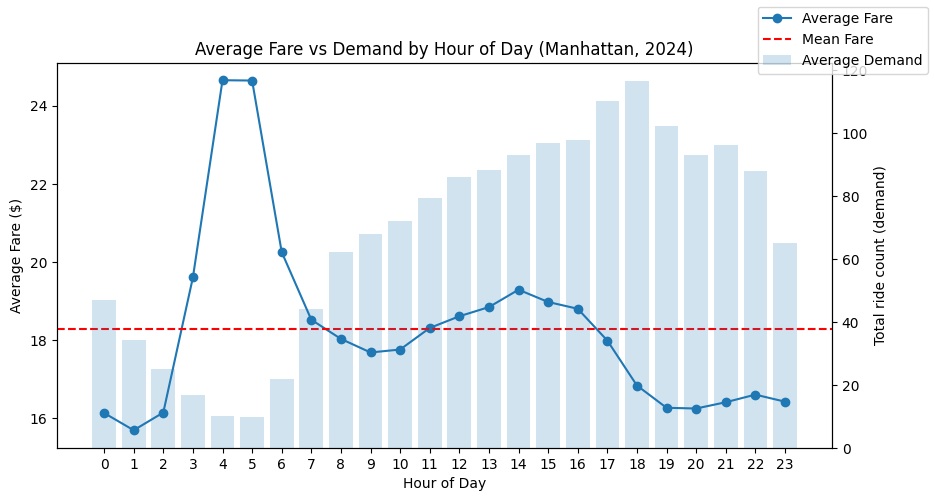

In [75]:
# Hourly - trends (with demand comparison)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Average fare per hour trendline
ax1.plot(hourly['pickup_hr'], hourly['avg_fare_amount'], marker='o', label="Average Fare")
# Mean average fare per hour (across all hours)
ax1.axhline(y=hourly['avg_fare_amount'].mean(), color='red', linestyle='--', label="Mean Fare")
ax1.set_xticks(range(0, 24)) # Show all hours of the day on the x-axis
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Average Fare ($)")

# Show demand in background for context
ax2 = ax1.twinx()
ax2.bar(hourly['pickup_hr'], hourly['avg_demand'], alpha=0.2, label="Average Demand")
ax2.set_ylabel("Total ride count (demand)")

plt.title("Average Fare vs Demand by Hour of Day (Manhattan, 2024)")
fig.legend(loc="upper right")
plt.show()

del hourly # (defined in cell above)

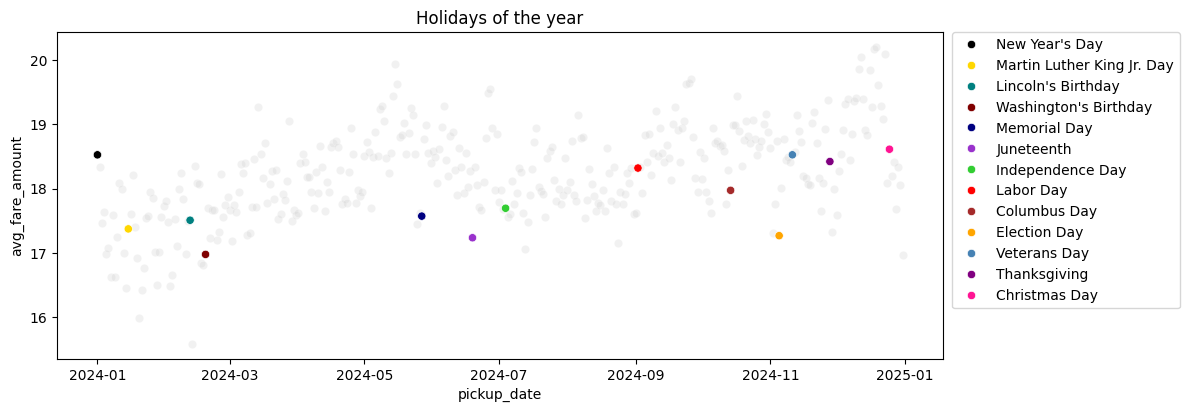

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Daily aggregate for EDA around weather
daily = df.groupby(['pickup_date']).agg(
    total_ride_count=('total_ride_count', 'sum'),
    avg_fare_amount = ('avg_fare_amount', 'mean')
).reset_index()
daily['day'] = daily['pickup_date'].dt.day_name()

# Join calendar
calendar = read_calendar_data()
daily = daily.merge(
    calendar,
    left_on='pickup_date',
    right_on='date',
    how='left'
)
daily['holiday'] = daily['holiday'].fillna("None")

# Look at holidays
palette = {
    'None': 'lightgrey',
    'Labor Day': 'red',
    'Veterans Day': 'steelblue',
    'Independence Day': 'limegreen',
    'Election Day': 'orange',
    'Thanksgiving': 'purple',
    'Christmas Day': 'deeppink',
    'Columbus Day': 'brown',
    'Memorial Day': 'navy',
    'Martin Luther King Jr. Day': 'gold',
    "Lincoln's Birthday": 'teal',
    "New Year's Day": 'black',
    "Washington's Birthday": 'maroon',
    'Juneteenth': 'darkorchid'
}
plt.figure(figsize=(12, 4))

# Base layer: non-holidays (grey, faint)
sns.scatterplot(
    data=daily[daily['holiday'] == 'None'],
    x='pickup_date',
    y='avg_fare_amount',
    color='lightgrey',
    alpha=0.3,
    legend=False
)

# Top layer: holidays (coloured, bold)
sns.scatterplot(
    data=daily[daily['holiday'] != 'None'],
    x='pickup_date',
    y='avg_fare_amount',
    hue='holiday',
    palette=palette,
    # s=60,
    # edgecolor='black'
)

# sns.scatterplot(daily, x='pickup_date', y='avg_fare_amount', hue='holiday', palette=palette)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.title("Holidays of the year")
plt.show()

del daily

### Geospatial EDA
Pickup zone

C:\Users\lgrun\AppData\Local\Temp\ipykernel_20456\798581139.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_zone = df.groupby(['pickup_zone'], as_index=False).agg(


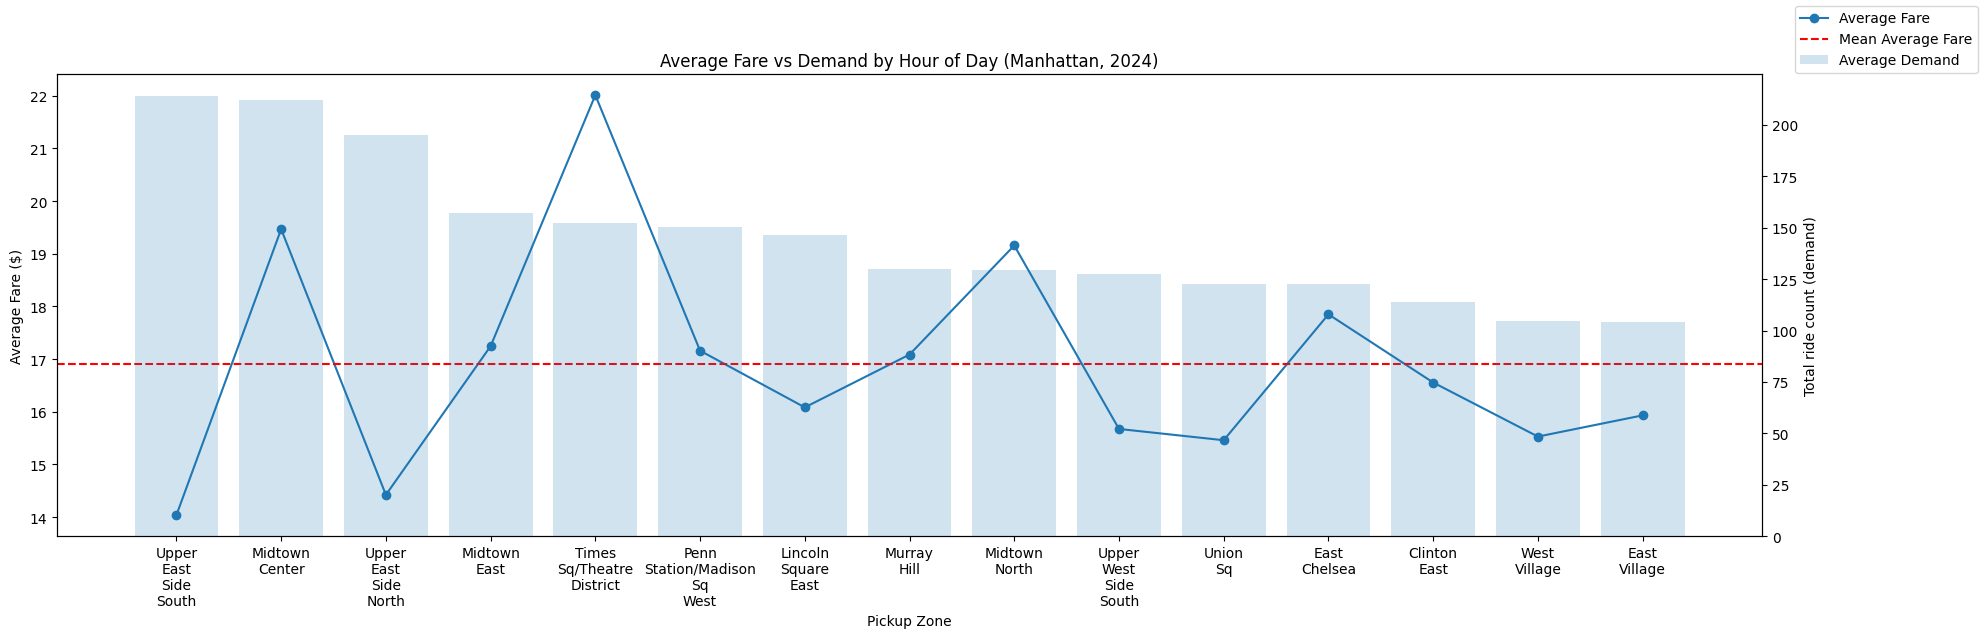

In [111]:
by_zone = df.groupby(['pickup_zone'], as_index=False).agg(
    avg_fare_amount = ('avg_fare_amount', 'mean'),
    avg_demand = ('total_ride_count', 'mean')
).sort_values('avg_demand', ascending=False).head(15)

fig, ax1 = plt.subplots(figsize=(22, 6))

# Average fare trendline
ax1.plot(by_zone['pickup_zone'], by_zone['avg_fare_amount'], marker='o', label="Average Fare")
# Mean average fare per hour (across all hours)
ax1.axhline(y=by_zone['avg_fare_amount'].mean(), color='red', linestyle='--', label="Mean Average Fare")
ax1.set_xlabel("Pickup Zone")
ax1.set_ylabel("Average Fare ($)")

# Show demand in background for context
ax2 = ax1.twinx()
ax2.bar(by_zone['pickup_zone'], by_zone['avg_demand'], alpha=0.2, label="Average Demand")
ax2.set_ylabel("Total ride count (demand)")

plt.title("Average Fare vs Demand by Hour of Day (Manhattan, 2024)")
fig.legend()

by_zone["zone_short_name"] = by_zone["pickup_zone"].str.replace(" ", "\n")
ax1.set_xticks(range(len(by_zone)))
ax1.set_xticklabels(by_zone["zone_short_name"])
plt.show()

del by_zone

### Weather EDA
Temperature, wind speed and cloud coverage

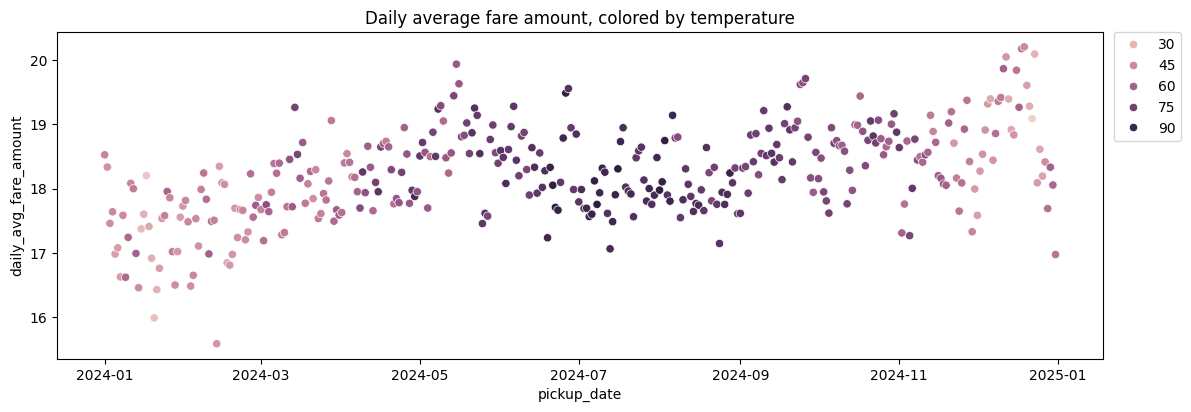

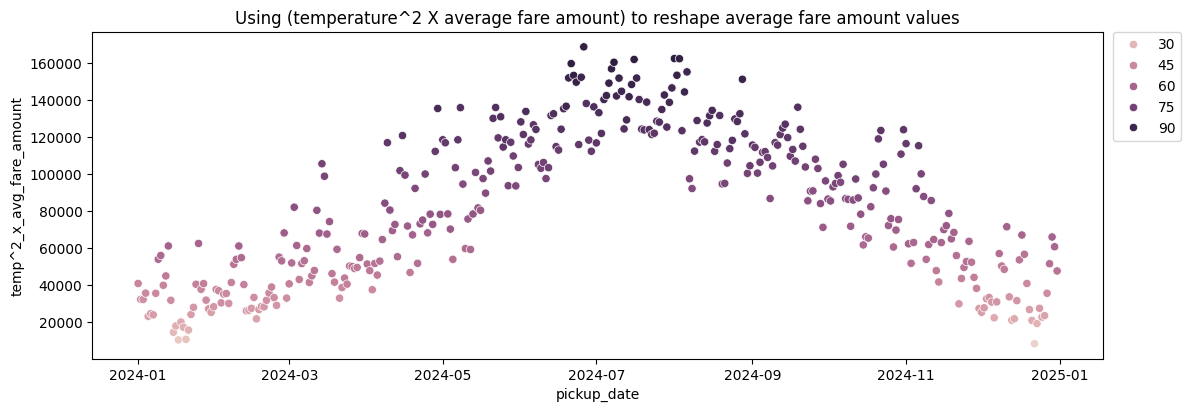

In [128]:
# Daily aggregate for EDA around weather
daily = df.groupby(['pickup_date']).agg(
    daily_avg_fare_amount=('avg_fare_amount', 'mean'),
    cloud_coverage=('cloud_coverage', 'mean'),
    max_temp=('max_temp', 'mean'),
    max_wind_speed=('max_wind_speed', 'mean')
).reset_index()
daily['day'] = daily['pickup_date'].dt.day_name()

# Does temperature requiring scaling?
daily['temp^2_x_avg_fare_amount'] = daily['max_temp'] * daily['max_temp'] * daily['daily_avg_fare_amount']

plt.figure(figsize=(12, 4))
sns.scatterplot(daily, x='pickup_date', y='daily_avg_fare_amount', hue='max_temp')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.title("Daily average fare amount, colored by temperature")
plt.show()

plt.figure(figsize=(12, 4))
sns.scatterplot(daily, x='pickup_date', y='temp^2_x_avg_fare_amount', hue='max_temp')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.title("Using (temperature^2 X average fare amount) to reshape average fare amount values")
plt.show()

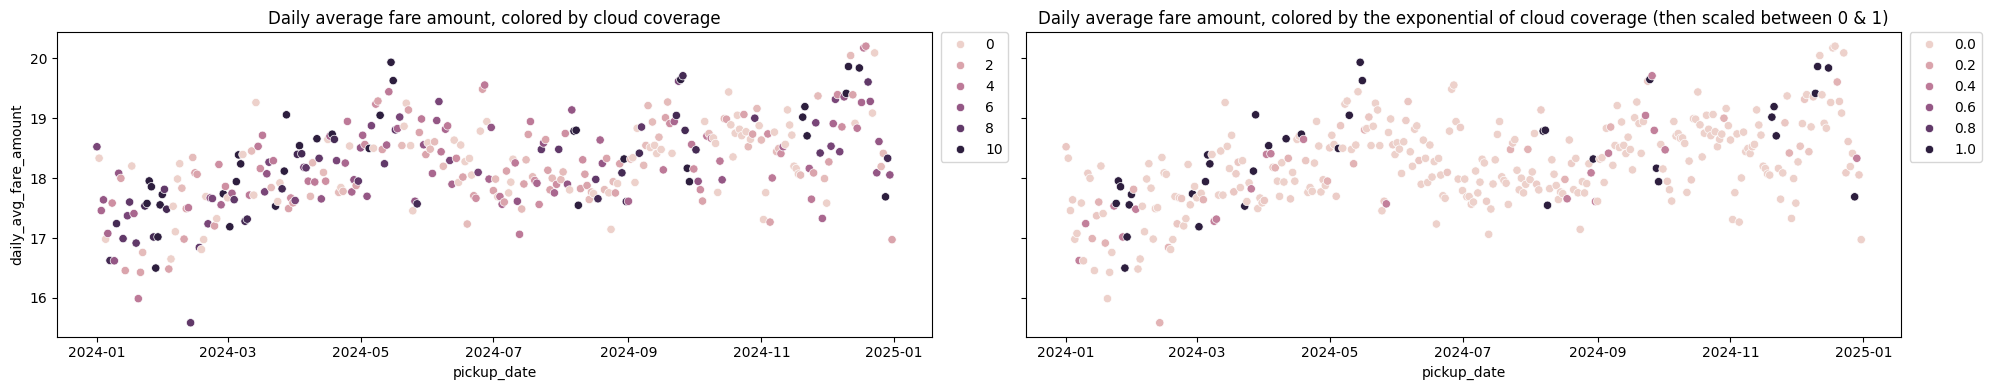

In [129]:
daily['exp_cloud_cover'] = np.exp(daily['cloud_coverage'])
daily['scaled_exp_cloud_cover'] = MinMaxScaler().fit_transform(daily['exp_cloud_cover'].values.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(20, 4), sharey=True)
sns.scatterplot(daily, x='pickup_date', y='daily_avg_fare_amount', hue='cloud_coverage', ax=axes[0])
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
axes[0].set_title("Daily average fare amount, colored by cloud coverage")
sns.scatterplot(daily, x='pickup_date', y='daily_avg_fare_amount', hue='scaled_exp_cloud_cover', ax=axes[1])
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
axes[1].set_title("Daily average fare amount, colored by the exponential of cloud coverage (then scaled between 0 & 1)")
plt.tight_layout()
plt.show()

del daily

## **[2.3]** Preprocessing

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# These columns only have a few categories
columns_to_onehot_encode = [
    'pickup_dow',
]

# These columns have LOADS of categories
columns_to_ordinal_encode = [
    'pickup_zone',
    'holiday',
]

# Split `y` BEFORE pipeline
y = df['avg_fare_amount']
X = df.drop(columns=['avg_fare_amount', 'pickup_date'])

# Pipeline
#
# Transfroms the categorical columns to onehot-encoded types
pipeline = ColumnTransformer(
    transformers=[
        #                               +--- `sparse_output=True` stops the encoder duplicating data
        #                               |
        ("onehot", OneHotEncoder(sparse_output=True), columns_to_onehot_encode), 
        ("ordinal", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_ordinal_encode),
    ],
    remainder='passthrough'
)
# pipeline.set_output(transform='pandas') # returning pandas cost too much memory
X_encoded = pipeline.fit_transform(X)

# Train vs Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=seed)

# Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=seed)

## **[2.4]** Linear Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

lin = Pipeline(steps=[
    ("scale", MaxAbsScaler()),
    ("model", LinearRegression()),
])
lin.fit(X_train, y_train)

# Training results
training_predictions = lin.predict(X_train)
analysis(y_train, training_predictions)

# Validation Results
validation_predictions = lin.predict(X_val)
analysis(y_val, validation_predictions)

# Test Results
test_predictions = lin.predict(X_test)
analysis(y_test, test_predictions)

# Clean up (for memory)
del lin
del training_predictions
del validation_predictions
del test_predictions

Mean Absolute Error: 	4.2490
Mean Squared Error: 	57.8570
R squared: 		0.1401
Mean Absolute Error: 	4.2510
Mean Squared Error: 	52.9418
R squared: 		0.1576
Mean Absolute Error: 	4.2417
Mean Squared Error: 	54.2818
R squared: 		0.1521


AttributeError: 'Pipeline' object has no attribute 'feature_importances_'

## **[2.5]** Random Forest Model

In [56]:
from sklearn.ensemble import RandomForestRegressor

# Fine-tuned model
rf = RandomForestRegressor(
    random_state=seed,
    n_jobs=1,            # parallel compute tends to crash memory (keep it at 1)
    n_estimators=120,    # enough trees to stabilise fares without dragging runtime too far
    min_samples_leaf=1,  # smooths very low / very high individual fare predictions
    max_depth=28,        # fares are still nonlinear, so allow deeper trees
    # max_features='sqrt',
)
rf.fit(X_train, y_train)

# Training results
training_predictions = rf.predict(X_train)
analysis(y_train, training_predictions)

# Validation Results
validation_predictions = rf.predict(X_val)
analysis(y_val, validation_predictions)

# Test Results
test_predictions = rf.predict(X_test)
analysis(y_test, test_predictions)

feature_importance(pipeline, rf)

# Clean up (for memory)
del rf
del training_predictions
del validation_predictions
del test_predictions

KeyboardInterrupt: 

## **[2.6]** MLP Neural Net Model

In [ ]:
from sklearn.neural_network import MLPRegressor

# Neural nets benefit from scaling much more than trees do
nn = Pipeline(steps=[
    ("scale", MaxAbsScaler()),
    ("model", MLPRegressor(
        random_state=seed,
        hidden_layer_sizes=(128, 64),
        activation='relu',
        alpha=1e-4,
        learning_rate_init=0.001,
        max_iter=600,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    )),
])
nn.fit(X_train, y_train)

# Training results
training_predictions = nn.predict(X_train)
analysis(y_train, training_predictions)

# Validation Results
validation_predictions = nn.predict(X_val)
analysis(y_val, validation_predictions)

# Test Results
test_predictions = nn.predict(X_test)_amount
analysis(y_test, test_predictions)

# Clean up (for memory)
del nn
del training_predictions
del validation_predictions
del test_predictions

KeyboardInterrupt: 